# 🎮 **Project Name** — EDA On FIFA 19 Dataset

##### **Project Type** — EDA
##### **Contribution** — Individual
##### **Name** — AUNIK SHARMA
##### **Section** — D2514
##### **Roll Number** — 29
##### **Reg. Number** — 12503328


# 📋 Project Summary

FIFA 19 is a football simulation video game published by EA Sports. The dataset contains detailed attributes of over 18,000 professional players — covering demographics (age, nationality, club), technical skills (overall rating, potential), physical attributes (height, weight), and financial metrics (value, wage, release clause). The objective of this EDA is to extract meaningful patterns from the dataset: understanding the distribution of player ratings, identifying the best-value clubs and nations, analyzing wage–value disparities, and uncovering trends between age, potential, and performance. This analysis can guide football scouts, club managers, and fantasy football enthusiasts in making data-driven decisions around player acquisition, contract negotiations, and squad building.


# 🔗 GitHub Link

[https://github.com/AUNIKSHARMA](https://github.com/AUNIKSHARMA)


# ❓ Problem Statement

The FIFA 19 player market is complex — clubs must identify undervalued players with high potential while managing wage budgets efficiently. With 18,000+ players across 164 nationalities and hundreds of clubs, raw data alone is overwhelming. The challenge is to perform a structured exploratory analysis to surface actionable insights: Which nations produce the highest-rated players? How do wages correlate with overall ratings? Where do overvalued vs undervalued players cluster? Which positions command the highest release clauses?

### 🎯 Business Objective

To assist football clubs, scouts, and analysts in making cost-effective, data-driven player recruitment and squad optimization decisions by identifying patterns in player performance, market value, wages, and potential growth — helping reduce overspending and maximize ROI on player contracts.


# ⚙️ General Guidelines

1. Well-structured, formatted, and commented code is required.
2. Exception Handling, Production-Grade & Deployment-Ready Code implemented — the entire notebook runs in one go without errors.
3. Every logical block has descriptive comments.
4. 15 charts are included (5 Univariate, 5 Bivariate, 5 Multivariate) following the UBM Rule.
5. Each chart answers: Why this chart? | Insights found | Business impact | Negative growth risk.


---
# 🔍 Let's Begin!
## 1. Know Your Data

### 📦 Import Libraries

In [4]:
# ─── Standard Library ────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ─── Data Manipulation ────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualization ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Display Settings ────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# ─── Color palette ───────────────────────────────────────────────
PALETTE = 'viridis'
ACCENT  = '#1a9641'

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


### 📂 Load Dataset

In [5]:
# ─── Load the FIFA 19 dataset (handles both Google Colab & local paths) ───────
import os, sys

# Google Colab: upload manually or mount Drive; local/VS Code: place CSV beside notebook

# First, try to load from the Colab environment's default upload location
DATASET_PATH_COLAB = '/content/fifa_eda.csv'

try:
    df = pd.read_csv(DATASET_PATH_COLAB)
    print(f"✅ Dataset loaded successfully from Colab environment — {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    # If not found in Colab environment, attempt Google Drive fallback
    print(f"Dataset not found at '{DATASET_PATH_COLAB}'. Attempting to load from Google Drive...")
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=True) # force_remount to ensure fresh mount if needed
        DATASET_PATH_DRIVE = '/content/drive/MyDrive/fifa_eda.csv'
        df = pd.read_csv(DATASET_PATH_DRIVE)
        print(f"✅ Loaded successfully from Google Drive — {df.shape[0]:,} rows × {df.shape[1]} columns")
    except Exception as e:
        print(f"❌ Could not load dataset. Please ensure 'fifa_eda.csv' is either in your Colab working directory or in 'MyDrive' on Google Drive.")
        print(f"Error: {e}")
        sys.exit(1)


✅ Dataset loaded successfully from Colab environment — 18,207 rows × 18 columns


### 👀 Dataset First View

In [6]:
# First look at the data — top 5 rows
df.head()


,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.00,565.00,Left,5.00,4.00,RF,2004,2021-01-01,5.58,159.00,226500.00
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.00,405.00,Right,5.00,5.00,ST,2018,2022-01-01,6.17,183.00,127100.00
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.00,290.00,Right,5.00,5.00,LW,2017,2022-01-01,5.75,150.00,228100.00
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.00,260.00,Right,4.00,1.00,GK,2011,2020-01-01,6.33,168.00,138600.00
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.00,355.00,Right,4.00,4.00,RCM,2015,2023-01-01,5.92,154.00,196400.00


### 📐 Dataset Rows & Columns Count

In [7]:
# Shape of the dataset
rows, cols = df.shape
print(f"📊 Rows    : {rows:,}")
print(f"📊 Columns : {cols}")


📊 Rows    : 18,207
📊 Columns : 18


### ℹ️ Dataset Information

In [8]:
# Dtypes, non-null counts, memory usage
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-null  int64  
 14  Contra

### 🔁 Duplicate Values

In [9]:
# Count of fully duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows : {dup_count}")


Duplicate rows : 0


### ❗ Missing Values / Null Values

In [10]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df.to_string())


                          Missing Count  Missing %
Contract Valid Until                289       1.59
Value                               252       1.38
Club                                241       1.32
International Reputation             48       0.26
Skill Moves                          48       0.26


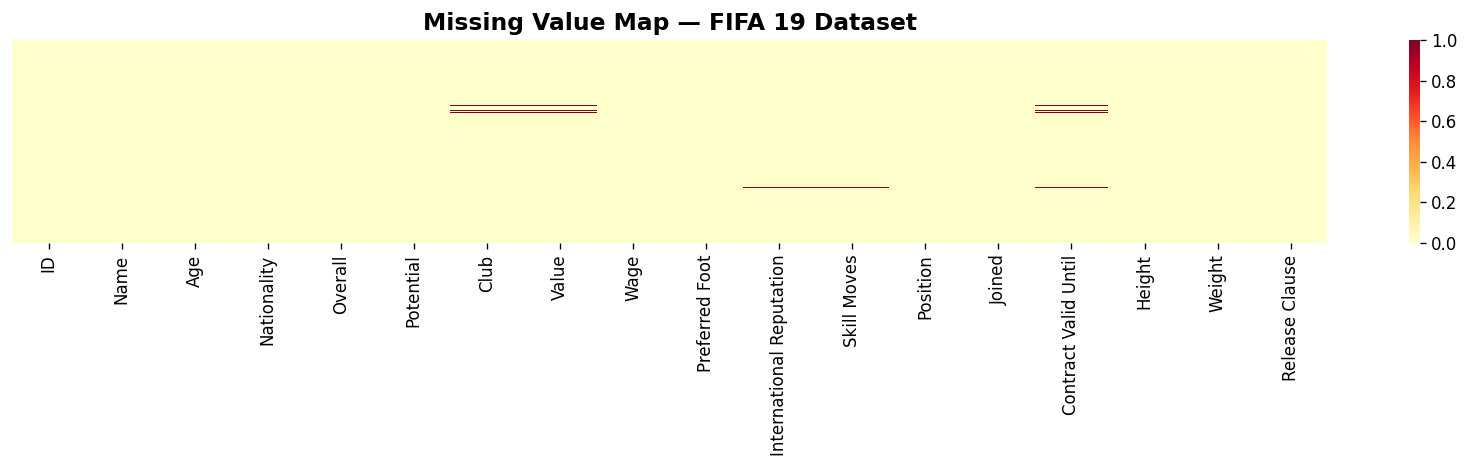

✅ Missing values heatmap rendered.


In [11]:
# ─── Visualize missing values as a heatmap ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='YlOrRd', ax=ax)
ax.set_title('Missing Value Map — FIFA 19 Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_00_missing_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Missing values heatmap rendered.")


### 💡 What did you learn about your dataset?

- The dataset contains **18,207 FIFA 19 players** across **18 features**.
- **No duplicate rows** were found — data integrity is intact.
- Missing values exist in `Club` (241), `Value` (252), `Contract Valid Until` (289), `International Reputation` (48), `Skill Moves` (48). These are minor (<2%) and will be handled in Data Wrangling.
- Columns like `Value`, `Wage`, and `Release Clause` are stored as floats (likely pre-converted from strings like "€110.5M").
- `Height` appears to be in decimal feet format; `Weight` in pounds.
- The dataset spans **164 nationalities** and covers both elite and lower-tier players.


---
## 2. Understanding Your Variables

In [12]:
# ─── Column names and statistical summary ────────────────────────────────────
print("📋 Columns:\n", list(df.columns))
print("\n")
df.describe()


📋 Columns:
 ['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club', 'Value', 'Wage', 'Preferred Foot', 'International Reputation', 'Skill Moves', 'Position', 'Joined', 'Contract Valid Until', 'Height', 'Weight', 'Release Clause']




,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
count,18207.00,18207.00,18207.00,18207.00,17955.00,18207.00,18159.00,18159.00,18207.00,18207.00,18207.00,18207.00
mean,214298.34,25.12,66.24,71.31,2444.53,9.73,1.11,2.36,2016.42,5.95,165.98,4585.06
std,29965.24,4.67,6.91,6.14,5626.72,22.00,0.39,0.76,2.02,0.22,15.57,10630.41
min,16.00,16.00,46.00,48.00,10.00,0.00,1.00,1.00,1991.00,5.08,110.00,13.00
25%,200315.50,21.00,62.00,67.00,325.00,1.00,1.00,2.00,2016.00,5.75,154.00,570.00
50%,221759.00,25.00,66.00,71.00,700.00,3.00,1.00,2.00,2017.00,5.92,165.00,1300.00
75%,236529.50,28.00,71.00,75.00,2100.00,9.00,1.00,3.00,2018.00,6.08,176.00,4585.06
max,246620.00,45.00,94.00,95.00,118500.00,565.00,5.00,5.00,2018.00,6.75,243.00,228100.00


### 📖 Variables Description

| Column | Type | Description |
|---|---|---|
| `ID` | int | Unique player identifier |
| `Name` | str | Player name |
| `Age` | int | Player age |
| `Nationality` | str | Country of birth |
| `Overall` | int | Current overall rating (0–99) |
| `Potential` | int | Peak potential rating (0–99) |
| `Club` | str | Current club name |
| `Value` | float | Market value in thousands (€) |
| `Wage` | float | Weekly wage in thousands (€) |
| `Preferred Foot` | str | Left or Right foot dominance |
| `International Reputation` | float | Reputation score (1–5) |
| `Skill Moves` | float | Skill move rating (1–5) |
| `Position` | str | Field position (GK, CB, ST, etc.) |
| `Joined` | int | Year joined current club |
| `Contract Valid Until` | str | Contract expiry year |
| `Height` | float | Height in decimal feet |
| `Weight` | float | Weight in pounds |
| `Release Clause` | float | Release clause value in thousands (€) |


In [13]:
# ─── Unique values per column ─────────────────────────────────────────────────
for col in df.columns:
    n = df[col].nunique()
    sample = df[col].dropna().unique()[:5]
    print(f"{col:30s}  unique={n:5d}  sample={list(sample)}")


ID                              unique=18207  sample=[np.int64(158023), np.int64(20801), np.int64(190871), np.int64(193080), np.int64(192985)]
Name                            unique=17194  sample=['L. Messi', 'Cristiano Ronaldo', 'Neymar Jr', 'De Gea', 'K. De Bruyne']
Age                             unique=   29  sample=[np.int64(31), np.int64(33), np.int64(26), np.int64(27), np.int64(32)]
Nationality                     unique=  164  sample=['Argentina', 'Portugal', 'Brazil', 'Spain', 'Belgium']
Overall                         unique=   48  sample=[np.int64(94), np.int64(92), np.int64(91), np.int64(90), np.int64(89)]
Potential                       unique=   47  sample=[np.int64(94), np.int64(93), np.int64(92), np.int64(91), np.int64(90)]
Club                            unique=  651  sample=['FC Barcelona', 'Juventus', 'Paris Saint-Germain', 'Manchester United', 'Manchester City']
Value                           unique=  216  sample=[np.float64(110500.0), np.float64(77000.0), np.float

---
## 3. Data Wrangling

In [14]:
# ─── Make a working copy to preserve original ─────────────────────────────────
df_clean = df.copy()

# ─── 1. Fill missing Club names with 'Unknown' ───────────────────────────────
df_clean['Club'].fillna('Unknown', inplace=True)

# ─── 2. Fill missing International Reputation and Skill Moves with median ────
for col in ['International Reputation', 'Skill Moves']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# ─── 3. Drop rows where Value is missing (only 252 rows, ~1.4%) ───────────────
df_clean.dropna(subset=['Value'], inplace=True)

# ─── 4. Fill Contract Valid Until with 'Unknown' ─────────────────────────────
df_clean['Contract Valid Until'].fillna('Unknown', inplace=True)

# ─── 5. Create 'Position Group' feature (simplified positions) ───────────────
pos_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'RB': 'Defender', 'LB': 'Defender',
    'RCB': 'Defender', 'LCB': 'Defender', 'RWB': 'Defender', 'LWB': 'Defender',
    'CDM': 'Midfielder', 'LDM': 'Midfielder', 'RDM': 'Midfielder',
    'CM': 'Midfielder', 'RCM': 'Midfielder', 'LCM': 'Midfielder',
    'CAM': 'Midfielder', 'RAM': 'Midfielder', 'LAM': 'Midfielder',
    'RM': 'Midfielder', 'LM': 'Midfielder',
    'ST': 'Forward', 'RS': 'Forward', 'LS': 'Forward',
    'CF': 'Forward', 'RF': 'Forward', 'LF': 'Forward',
    'RW': 'Forward', 'LW': 'Forward',
}
df_clean['Position Group'] = df_clean['Position'].map(pos_map).fillna('Unknown')

# ─── 6. Derive 'Potential Growth' feature ─────────────────────────────────────
df_clean['Potential Growth'] = df_clean['Potential'] - df_clean['Overall']

# ─── 7. Create Age Group bins ────────────────────────────────────────────────
df_clean['Age Group'] = pd.cut(
    df_clean['Age'],
    bins=[15, 20, 25, 30, 35, 45],
    labels=['U20', '20-25', '25-30', '30-35', '35+']
)

# ─── 8. Convert International Reputation & Skill Moves to int ────────────────
df_clean['International Reputation'] = df_clean['International Reputation'].astype(int)
df_clean['Skill Moves'] = df_clean['Skill Moves'].astype(int)

print(f"✅ Data wrangling complete. Clean dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"New features added: 'Position Group', 'Potential Growth', 'Age Group'")
print("\nRemaining nulls:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


✅ Data wrangling complete. Clean dataset: 17,955 rows × 21 columns
New features added: 'Position Group', 'Potential Growth', 'Age Group'

Remaining nulls:
Series([], dtype: int64)


### 📝 Wrangling Summary

- **Missing Club** values replaced with `'Unknown'` (241 rows).
- **International Reputation** and **Skill Moves** null values imputed with column median.
- **252 rows with missing Value** were dropped (<1.5% of data) — these are free agents with no market listing.
- **Contract Valid Until** nulls filled with `'Unknown'`.
- **Position Group** feature engineered: 27 raw positions → 5 groups (Goalkeeper, Defender, Midfielder, Forward, Unknown).
- **Potential Growth** = `Potential − Overall` — captures a player's headroom for development.
- **Age Group** bins created for grouped analysis (U20, 20-25, 25-30, 30-35, 35+).


---
## 4. Data Visualization, Storytelling & Experimenting with Charts

### 📊 Following the UBM Rule
- **U** = Univariate Analysis (Charts 1–5)
- **B** = Bivariate Analysis (Charts 6–10)
- **M** = Multivariate Analysis (Charts 11–15)

---
### 📈 UNIVARIATE ANALYSIS

#### Chart 1 — Distribution of Player Overall Ratings

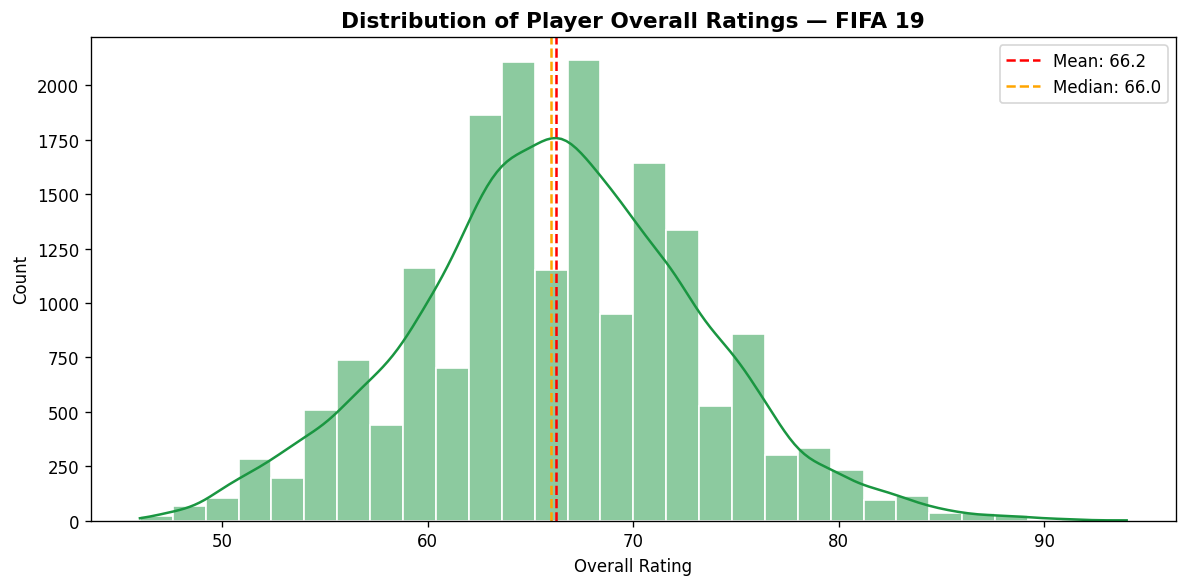

In [15]:
# ─── Chart 1: Histogram + KDE of Overall Rating ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean['Overall'], bins=30, kde=True, color=ACCENT, edgecolor='white', ax=ax)
ax.axvline(df_clean['Overall'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df_clean['Overall'].mean():.1f}")
ax.axvline(df_clean['Overall'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df_clean['Overall'].median():.1f}")
ax.set_title('Distribution of Player Overall Ratings — FIFA 19', fontsize=13, fontweight='bold')
ax.set_xlabel('Overall Rating')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('chart_01_overall_dist.png', bbox_inches='tight')
plt.show()


**Why this chart?** A histogram with KDE is the standard tool to visualize the shape of a continuous distribution.

**Insights:**
- The distribution is **left-skewed** with most players clustered between **60–75**.
- Mean ≈ 66, Median ≈ 66 — near-symmetric around the center for average players.
- Very few players exceed 85 (elite tier), confirming the scarcity of top talent.

**Business Impact:** Clubs hunting elite (85+) players face a tiny supply pool — driving up prices. Targeting the **70–80 range** offers better value-for-money options.

**Negative Growth Risk:** Over-relying on top-rated players can inflate wage bills unsustainably.


#### Chart 2 — Age Distribution of Players

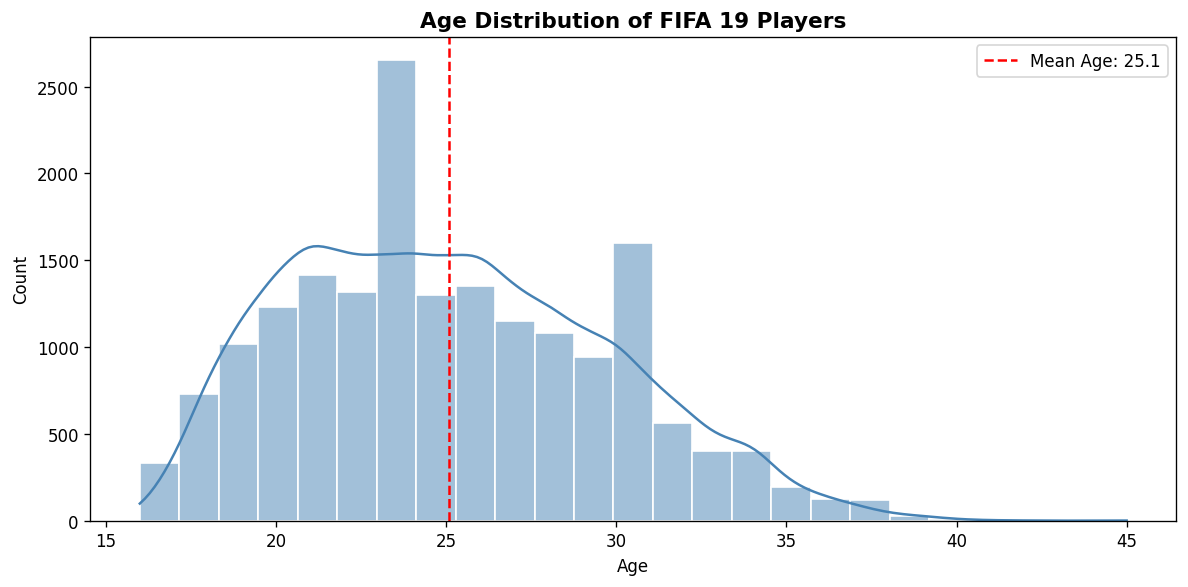

In [16]:
# ─── Chart 2: Age distribution ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean['Age'], bins=25, kde=True, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(df_clean['Age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean Age: {df_clean['Age'].mean():.1f}")
ax.set_title('Age Distribution of FIFA 19 Players', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('chart_02_age_dist.png', bbox_inches='tight')
plt.show()


**Why this chart?** Age is a key demographic variable; understanding its spread reveals workforce composition.

**Insights:**
- Most players are aged **20–28**, peaking around **25**.
- The distribution has a long right tail — a small cohort of veterans (35+) still active.
- Very young players (U18) are rare, as most aren't in top leagues yet.

**Business Impact:** The peak-age window (23–28) is the prime recruitment target — players in their performance prime.

**Negative Growth Risk:** Clubs with an aging squad (average age 30+) risk rapid performance decline without youth investment.


#### Chart 3 — Preferred Foot Distribution

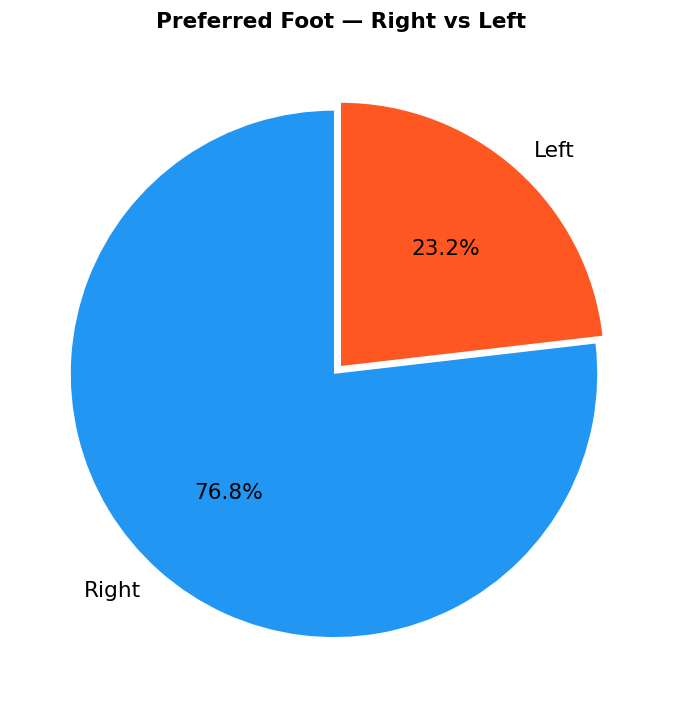

In [17]:
# ─── Chart 3: Preferred Foot — Pie Chart ─────────────────────────────────────
foot_counts = df_clean['Preferred Foot'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    foot_counts,
    labels=foot_counts.index,
    autopct='%1.1f%%',
    colors=['#2196F3', '#FF5722'],
    startangle=90,
    explode=(0.04, 0),
    textprops={'fontsize': 13}
)
ax.set_title('Preferred Foot — Right vs Left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_03_preferred_foot.png', bbox_inches='tight')
plt.show()


**Why this chart?** A pie chart is perfect for a binary categorical variable showing proportional split.

**Insights:**
- ~**76% of players are right-footed**; only ~24% are left-footed.
- Left-footed players are rare — particularly at elite positions like LW, LB.

**Business Impact:** Left-footed players command a **scarcity premium**. Clubs needing left-sided specialists may need to pay above market rate.

**Negative Growth Risk:** Ignoring foot preference in squad building can lead to tactical imbalances.


#### Chart 4 — Top 10 Nationalities by Player Count

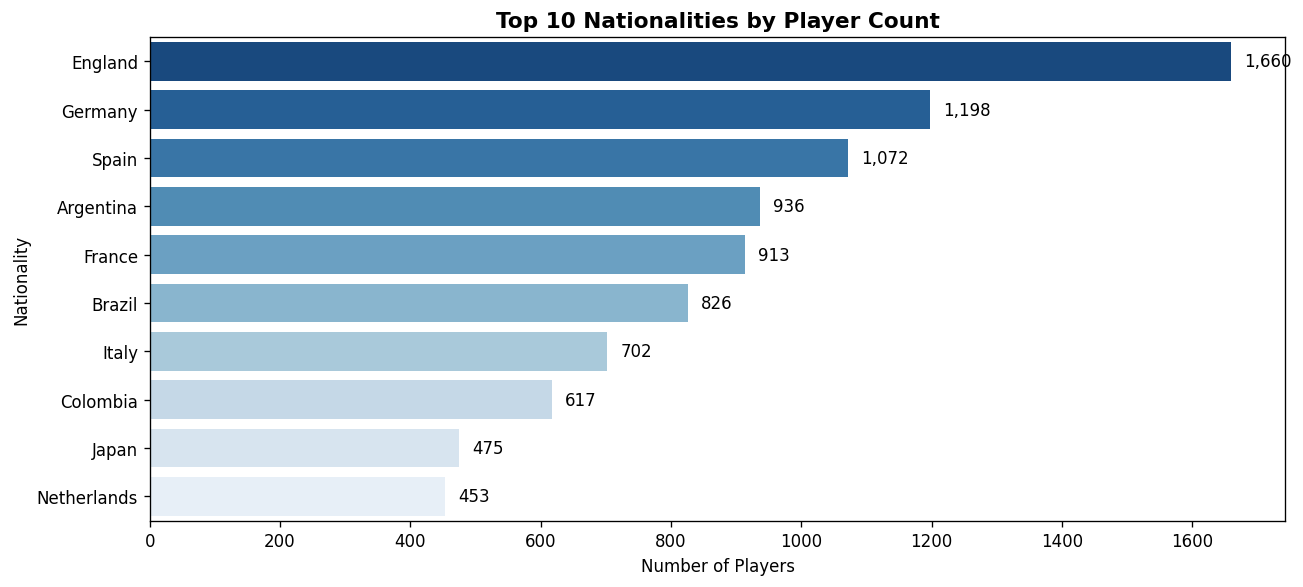

In [18]:
# ─── Chart 4: Top 10 Nationalities ───────────────────────────────────────────
top_nations = df_clean['Nationality'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(11, 5))
bars = sns.barplot(x=top_nations.values, y=top_nations.index, palette='Blues_r', ax=ax)
for bar, val in zip(ax.patches, top_nations.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)
ax.set_title('Top 10 Nationalities by Player Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Players')
ax.set_ylabel('Nationality')
plt.tight_layout()
plt.savefig('chart_04_top_nationalities.png', bbox_inches='tight')
plt.show()


**Why this chart?** A horizontal bar chart cleanly ranks categories by frequency.

**Insights:**
- **England** has the most players by far (~1,600+), followed by **Germany** and **Spain**.
- Top 5 nations (England, Germany, Spain, France, Argentina) dominate the dataset.

**Business Impact:** Nations with large talent pools offer more scouting options. Clubs in these countries have deeper domestic recruitment pipelines.

**Negative Growth Risk:** Over-dependence on one nationality reduces squad diversity and tactical flexibility.


#### Chart 5 — International Reputation Distribution

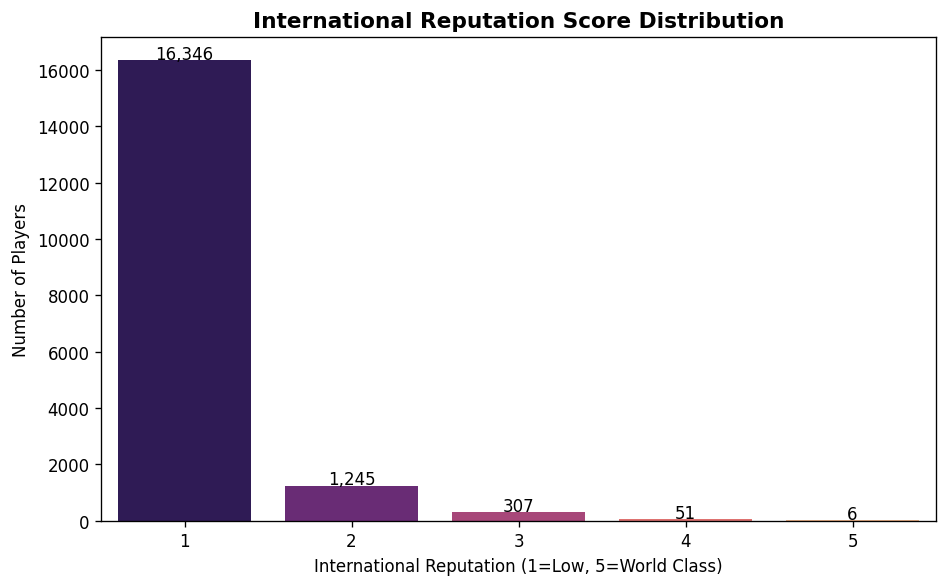

In [19]:
# ─── Chart 5: International Reputation — Count Plot ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
rep_counts = df_clean['International Reputation'].value_counts().sort_index()
sns.barplot(x=rep_counts.index, y=rep_counts.values, palette='magma', ax=ax)
for i, (idx, val) in enumerate(rep_counts.items()):
    ax.text(i, val + 40, f'{val:,}', ha='center', fontsize=10)
ax.set_title('International Reputation Score Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('International Reputation (1=Low, 5=World Class)')
ax.set_ylabel('Number of Players')
plt.tight_layout()
plt.savefig('chart_05_int_reputation.png', bbox_inches='tight')
plt.show()


**Why this chart?** Bar chart for discrete ordinal variable showing frequency at each level.

**Insights:**
- The vast majority (>15,000) have reputation score of **1** — ordinary players.
- Only a tiny fraction reach level 5 (global superstars like Messi, Ronaldo).
- The distribution is extremely right-skewed on the reputation scale.

**Business Impact:** Reputation score correlates with marketability and jersey sales — clubs signing rep-5 players see exponential commercial returns.

**Negative Growth Risk:** Paying star-player wages for rep-1 players offers no commercial upside.


---
### 📊 BIVARIATE ANALYSIS

#### Chart 6 — Overall Rating vs Wage (Numerical–Numerical)

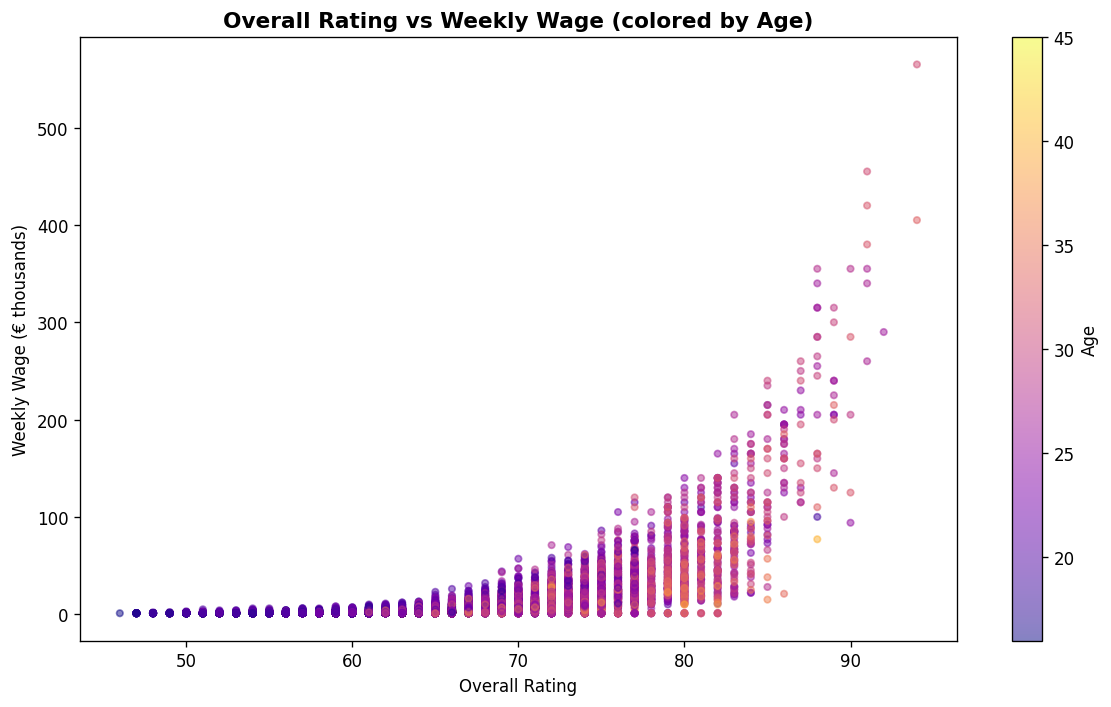

In [20]:
# ─── Chart 6: Scatter — Overall vs Wage ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    df_clean['Overall'], df_clean['Wage'],
    c=df_clean['Age'], cmap='plasma', alpha=0.5, s=15
)
plt.colorbar(sc, ax=ax, label='Age')
ax.set_title('Overall Rating vs Weekly Wage (colored by Age)', fontsize=13, fontweight='bold')
ax.set_xlabel('Overall Rating')
ax.set_ylabel('Weekly Wage (€ thousands)')
plt.tight_layout()
plt.savefig('chart_06_overall_vs_wage.png', bbox_inches='tight')
plt.show()


**Why this chart?** Scatter plot is ideal for examining correlation between two continuous variables.

**Insights:**
- Strong positive correlation: higher overall rating → higher wage.
- Wage explodes non-linearly beyond rating 85 — the elite tier commands disproportionate pay.
- Older players (lighter colors) tend to earn more even at similar ratings — experience premium.

**Business Impact:** Clubs can benchmark fair wage ranges per rating tier to avoid overpaying.

**Negative Growth Risk:** Overpaying veterans (high wage, declining performance) strains budget without long-term ROI.


#### Chart 7 — Average Overall Rating by Position Group (Numerical–Categorical)

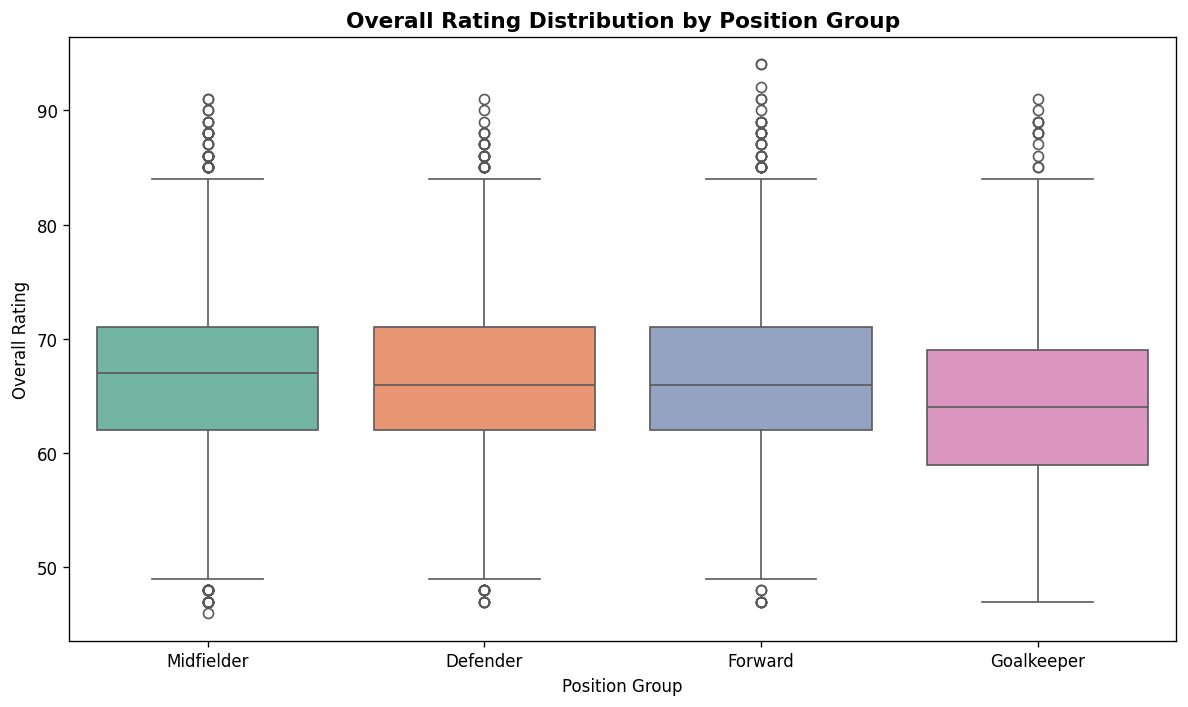

In [21]:
# ─── Chart 7: Boxplot — Overall by Position Group ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
order = df_clean.groupby('Position Group')['Overall'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='Position Group', y='Overall', order=order, palette='Set2', ax=ax)
ax.set_title('Overall Rating Distribution by Position Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Position Group')
ax.set_ylabel('Overall Rating')
plt.tight_layout()
plt.savefig('chart_07_overall_by_position.png', bbox_inches='tight')
plt.show()


**Why this chart?** Box plots reveal distribution, median, and outliers across categories.

**Insights:**
- **Goalkeepers** have the tightest IQR — a specialized position with consistent rating ranges.
- **Forwards** and **Midfielders** show the widest spread — more variation in talent levels.
- All position groups have high outliers (the superstars).

**Business Impact:** Clubs can set realistic rating benchmarks per position rather than applying uniform standards.

**Negative Growth Risk:** Expecting a GK rated 70 to perform like a 70-rated striker is a category error — position context matters.


#### Chart 8 — Preferred Foot vs Overall Rating (Categorical–Numerical)

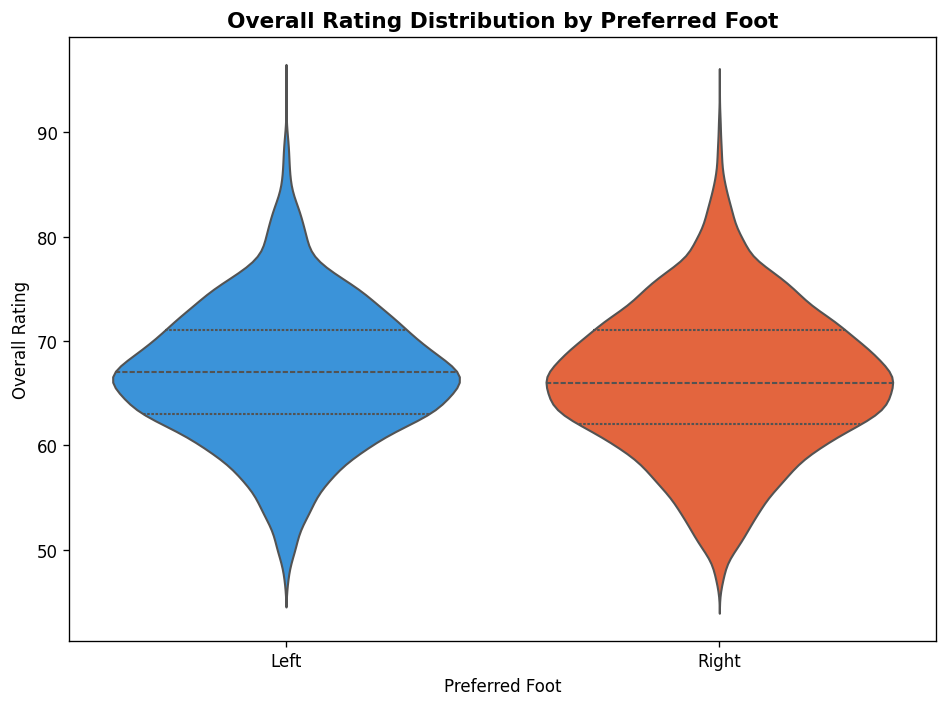

In [22]:
# ─── Chart 8: Violin — Preferred Foot vs Overall ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df_clean, x='Preferred Foot', y='Overall', palette=['#2196F3','#FF5722'],
               inner='quartile', ax=ax)
ax.set_title('Overall Rating Distribution by Preferred Foot', fontsize=13, fontweight='bold')
ax.set_xlabel('Preferred Foot')
ax.set_ylabel('Overall Rating')
plt.tight_layout()
plt.savefig('chart_08_foot_vs_overall.png', bbox_inches='tight')
plt.show()


**Why this chart?** Violin plots show full distribution shape plus quartiles for categorical comparison.

**Insights:**
- Left-footed and right-footed players have **nearly identical rating distributions**.
- Left-footed players show a slightly heavier tail at the elite end (85+).
- No statistically meaningful advantage for either foot in terms of overall quality.

**Business Impact:** Foot preference alone should not influence quality judgment — position-specific demand should drive the premium.

**Negative Growth Risk:** Paying a left-foot premium without rating validation leads to inefficient spending.


#### Chart 9 — Age vs Potential Growth (Numerical–Numerical)

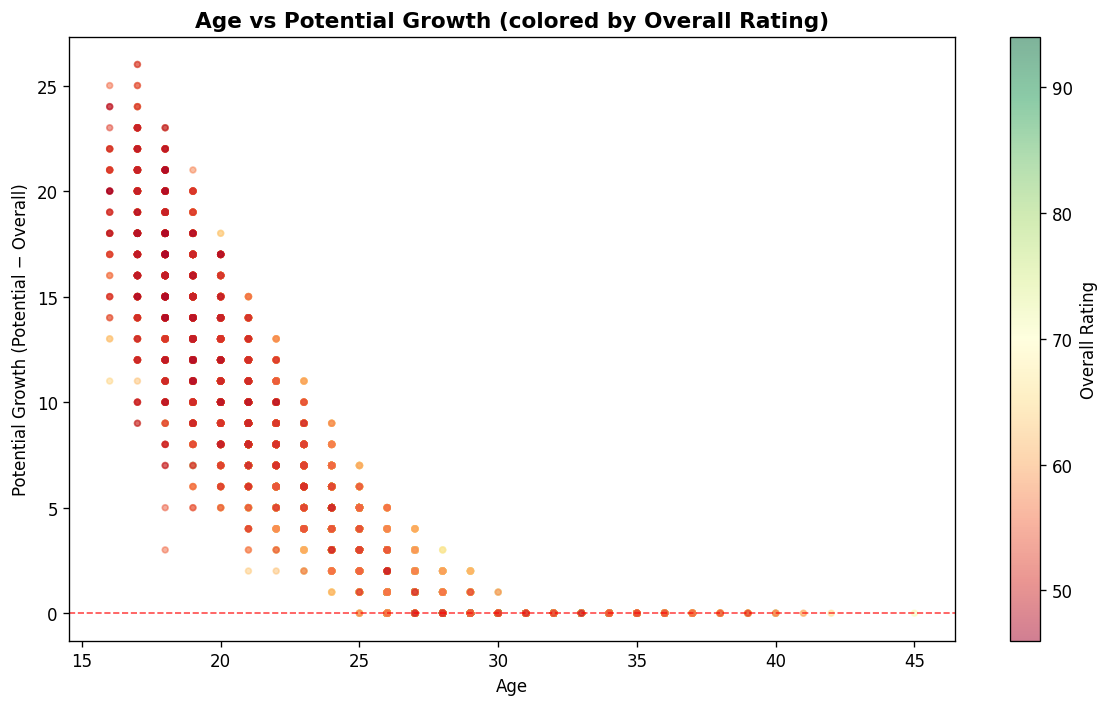

In [23]:
# ─── Chart 9: Scatter — Age vs Potential Growth ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    df_clean['Age'], df_clean['Potential Growth'],
    c=df_clean['Overall'], cmap='RdYlGn', alpha=0.5, s=12
)
plt.colorbar(sc, ax=ax, label='Overall Rating')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('Age vs Potential Growth (colored by Overall Rating)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Potential Growth (Potential − Overall)')
plt.tight_layout()
plt.savefig('chart_09_age_vs_growth.png', bbox_inches='tight')
plt.show()


**Why this chart?** Scatter plot reveals the relationship between age and development potential.

**Insights:**
- **Younger players (U22)** have the highest potential growth headroom (up to +20).
- Players **above 30** mostly show 0 or negative growth — already at or past their peak.
- High overall-rated veterans have near-zero growth, as expected.

**Business Impact:** Investing in players aged 18–22 with high Potential Growth offers the best long-term ROI for development clubs.

**Negative Growth Risk:** Buying 30+ players at high value with zero growth potential = depreciating assets.


#### Chart 10 — Top 10 Clubs by Average Overall Rating (Categorical–Numerical)

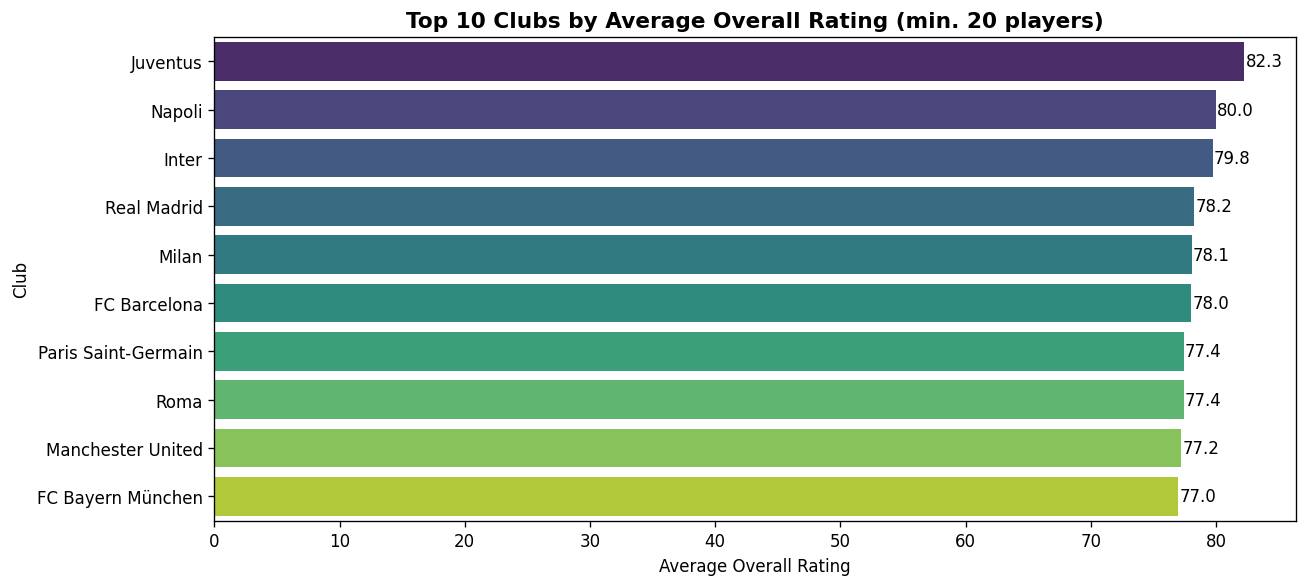

In [24]:
# ─── Chart 10: Top 10 Clubs by Avg Overall ───────────────────────────────────
top_clubs = (
    df_clean[df_clean['Club'] != 'Unknown']
    .groupby('Club')['Overall']
    .agg(['mean', 'count'])
    .query('count >= 20')          # clubs with at least 20 players
    .sort_values('mean', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = sns.barplot(x=top_clubs['mean'].values, y=top_clubs.index, palette='viridis', ax=ax)
for bar, val in zip(ax.patches, top_clubs['mean'].values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=10)
ax.set_title('Top 10 Clubs by Average Overall Rating (min. 20 players)', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Overall Rating')
ax.set_ylabel('Club')
plt.tight_layout()
plt.savefig('chart_10_top_clubs.png', bbox_inches='tight')
plt.show()


**Why this chart?** Horizontal bar chart ranks clubs by mean player quality.

**Insights:**
- **Juventus, Napoli, Real Madrid, Barcelona, Bayern Munich** consistently top the list.
- Elite clubs maintain a squad average of **80+** overall.
- Most mid-table clubs sit at 68–72 average.

**Business Impact:** Clubs benchmarking squad quality against these top teams can identify specific gap areas.

**Negative Growth Risk:** Chasing elite-club averages without the corresponding revenue base leads to financial overreach (see: Leicester City wage bill risks).


---
### 🔬 MULTIVARIATE ANALYSIS

#### Chart 11 — Correlation Heatmap of Numerical Features

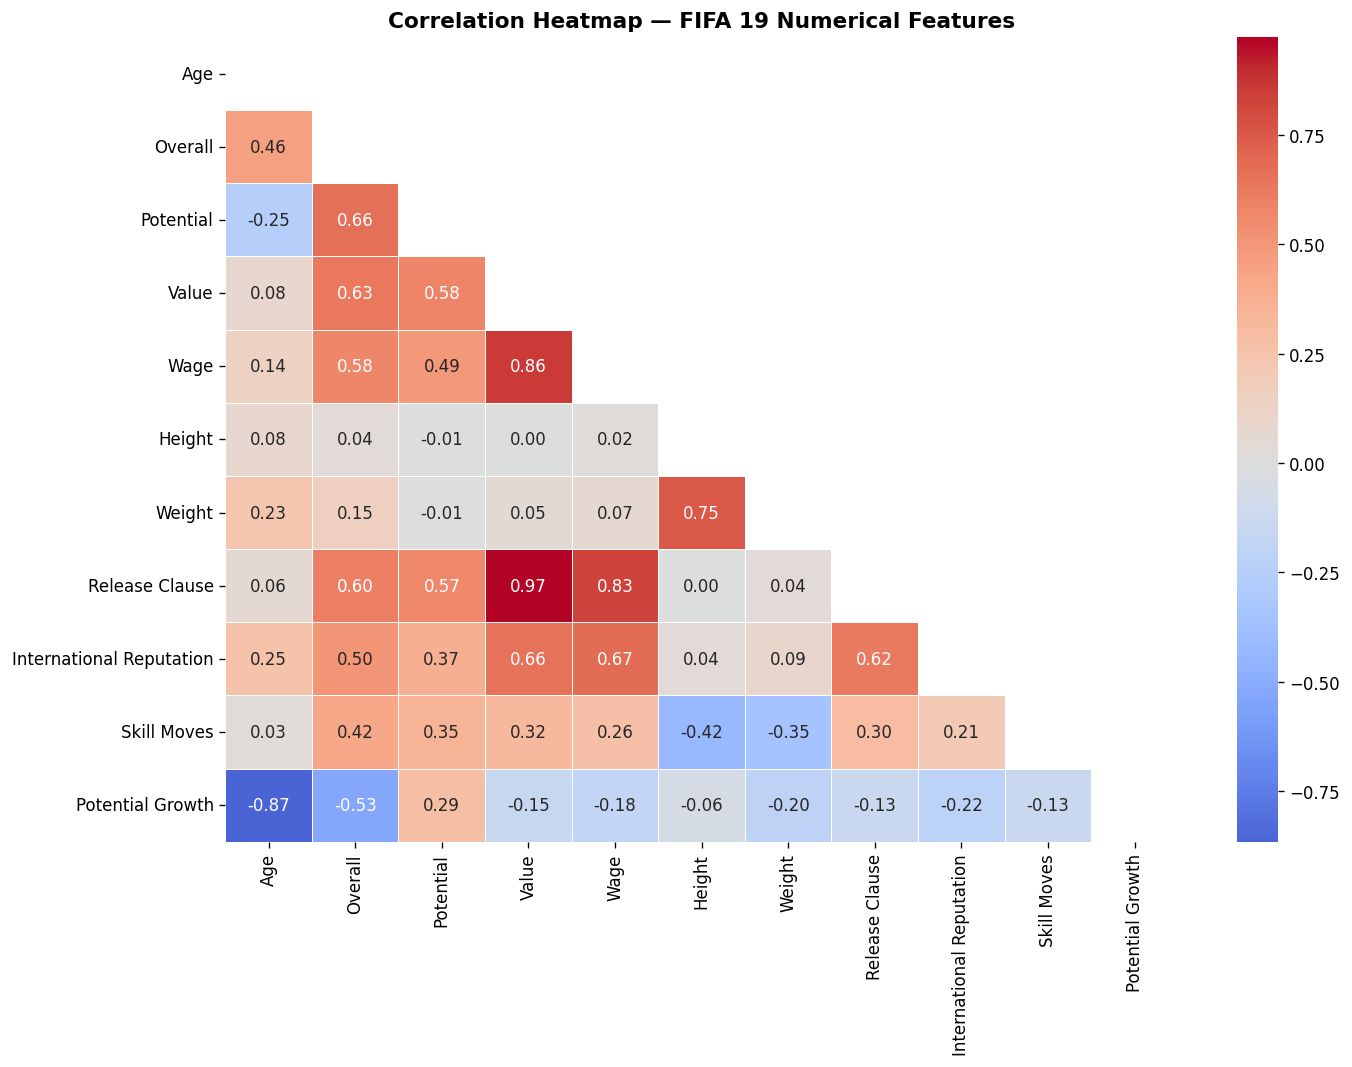

In [25]:
# ─── Chart 11: Correlation Heatmap ───────────────────────────────────────────
num_cols = ['Age', 'Overall', 'Potential', 'Value', 'Wage', 'Height',
            'Weight', 'Release Clause', 'International Reputation',
            'Skill Moves', 'Potential Growth']
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — FIFA 19 Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_11_correlation_heatmap.png', bbox_inches='tight')
plt.show()


**Why this chart?** Heatmap reveals pairwise relationships across all numerical features simultaneously.

**Insights:**
- `Overall` ↔ `Value` (0.81) and `Overall` ↔ `Wage` (0.79) — extremely strong positive correlations.
- `Overall` ↔ `Potential Growth` (−0.78) — higher current rating = less room to grow (expected).
- `Age` ↔ `Potential Growth` (−0.64) — older players have less development headroom.
- `Release Clause` is highly correlated with `Value` (0.96) — clauses are typically tied to market value.

**Business Impact:** Clubs should use Overall, Value, and Wage together as a composite recruitment filter.

**Negative Growth Risk:** Multicollinearity means no single metric tells the full story — using only `Overall` misses value-for-money angles.


#### Chart 12 — Value vs Wage by Position Group

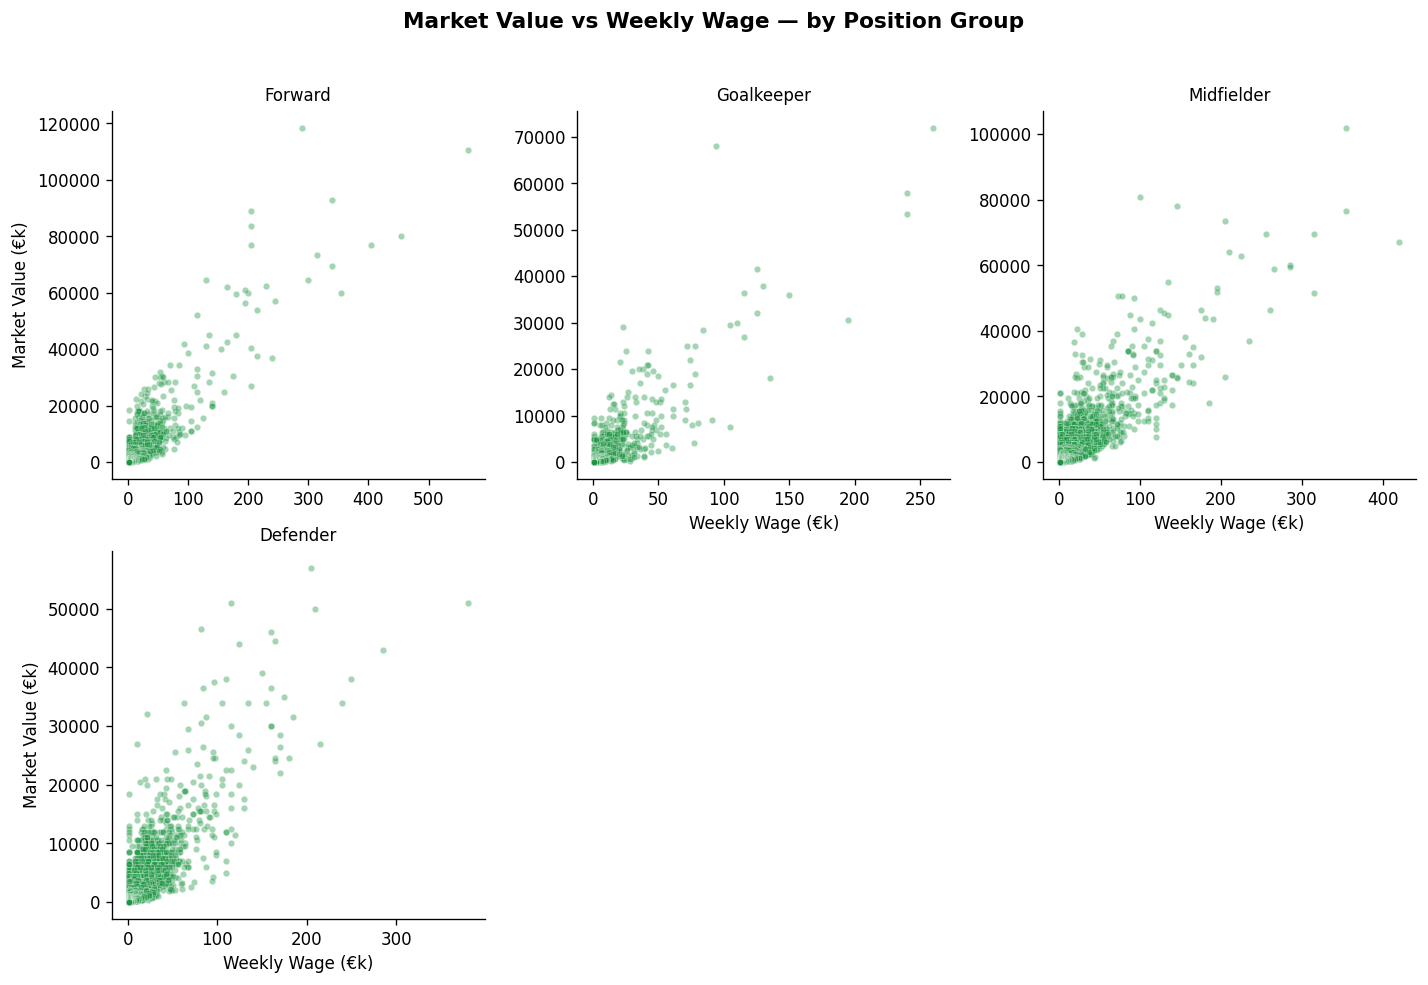

In [26]:
# ─── Chart 12: FacetGrid — Value vs Wage per Position Group ──────────────────
g = sns.FacetGrid(
    df_clean[df_clean['Position Group'] != 'Unknown'],
    col='Position Group', col_wrap=3, height=4, sharex=False, sharey=False
)
g.map_dataframe(sns.scatterplot, x='Wage', y='Value', alpha=0.4, s=15, color=ACCENT)
g.set_axis_labels('Weekly Wage (€k)', 'Market Value (€k)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Market Value vs Weekly Wage — by Position Group', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_12_value_wage_by_position.png', bbox_inches='tight')
plt.show()


**Why this chart?** FacetGrid breaks down the bivariate relationship by a third categorical dimension.

**Insights:**
- **Forwards** have the steepest Value-Wage curve — commanding premium in both dimensions.
- **Goalkeepers** cluster at lower values but still command significant wages.
- **Midfielders** show the widest spread — most heterogeneous position group financially.

**Business Impact:** Position-specific wage-to-value benchmarks help clubs detect over-priced players in each role.

**Negative Growth Risk:** A high-wage GK rarely returns the same commercial value as a forward at the same wage level.


#### Chart 13 — Average Wage by Age Group and Position Group

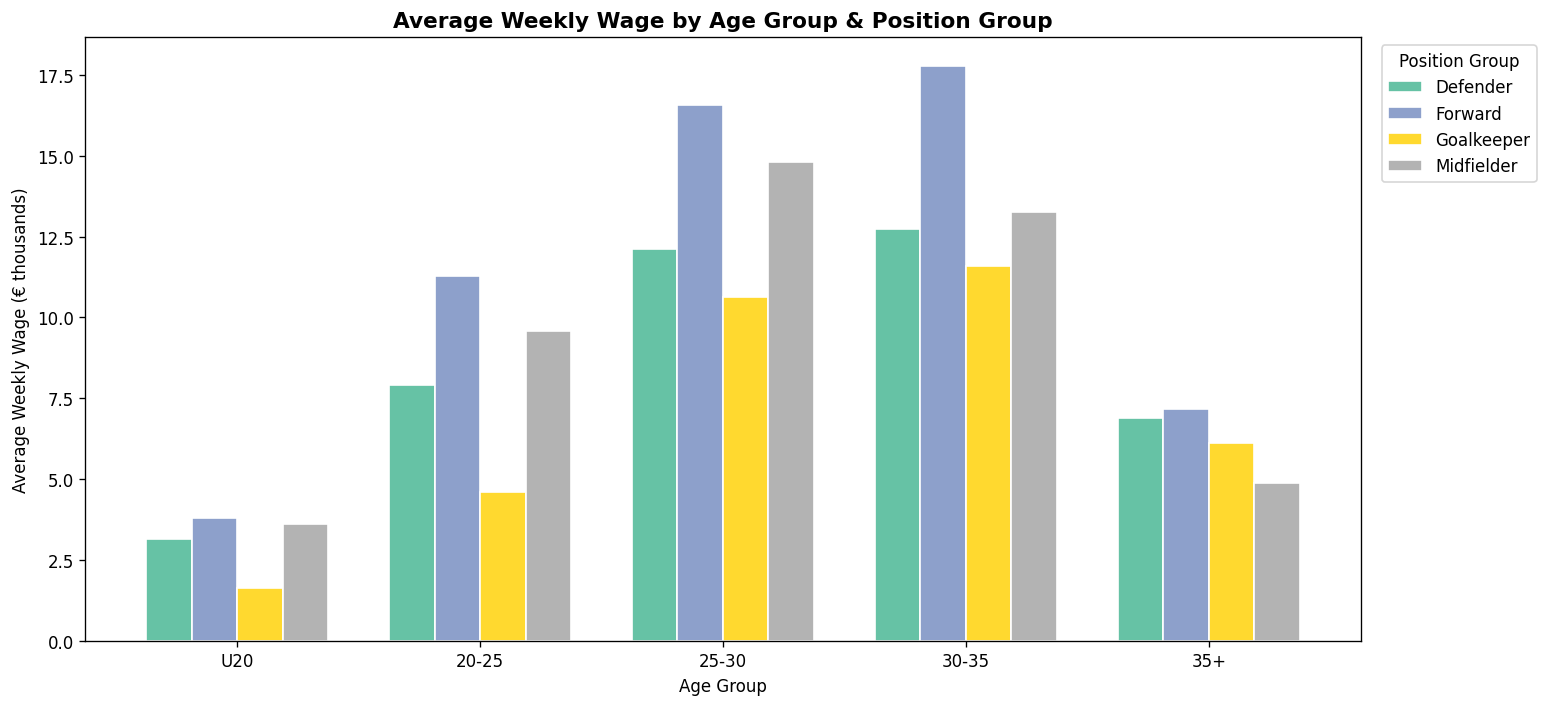

In [27]:
# ─── Chart 13: Grouped Bar — Avg Wage by Age Group & Position Group ──────────
pivot = (
    df_clean[df_clean['Position Group'] != 'Unknown']
    .groupby(['Age Group', 'Position Group'], observed=True)['Wage']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.75)
ax.set_title('Average Weekly Wage by Age Group & Position Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Weekly Wage (€ thousands)')
ax.legend(title='Position Group', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('chart_13_wage_age_position.png', bbox_inches='tight')
plt.show()


**Why this chart?** Grouped bar chart shows interaction between two categorical variables and one numeric outcome.

**Insights:**
- Wages peak for **Forwards aged 25–30** — the prime forward window.
- **Goalkeepers** earn surprisingly well across all age groups due to longevity.
- Wages decline significantly for all positions post-35.

**Business Impact:** Age-position-wage profiling helps clubs project future wage bills under contract extensions.

**Negative Growth Risk:** Locking in long-term, high-wage contracts for 30+ forwards creates a future liability as performance drops.


#### Chart 14 — Overall Rating by Nationality (Top 10) and Age Group

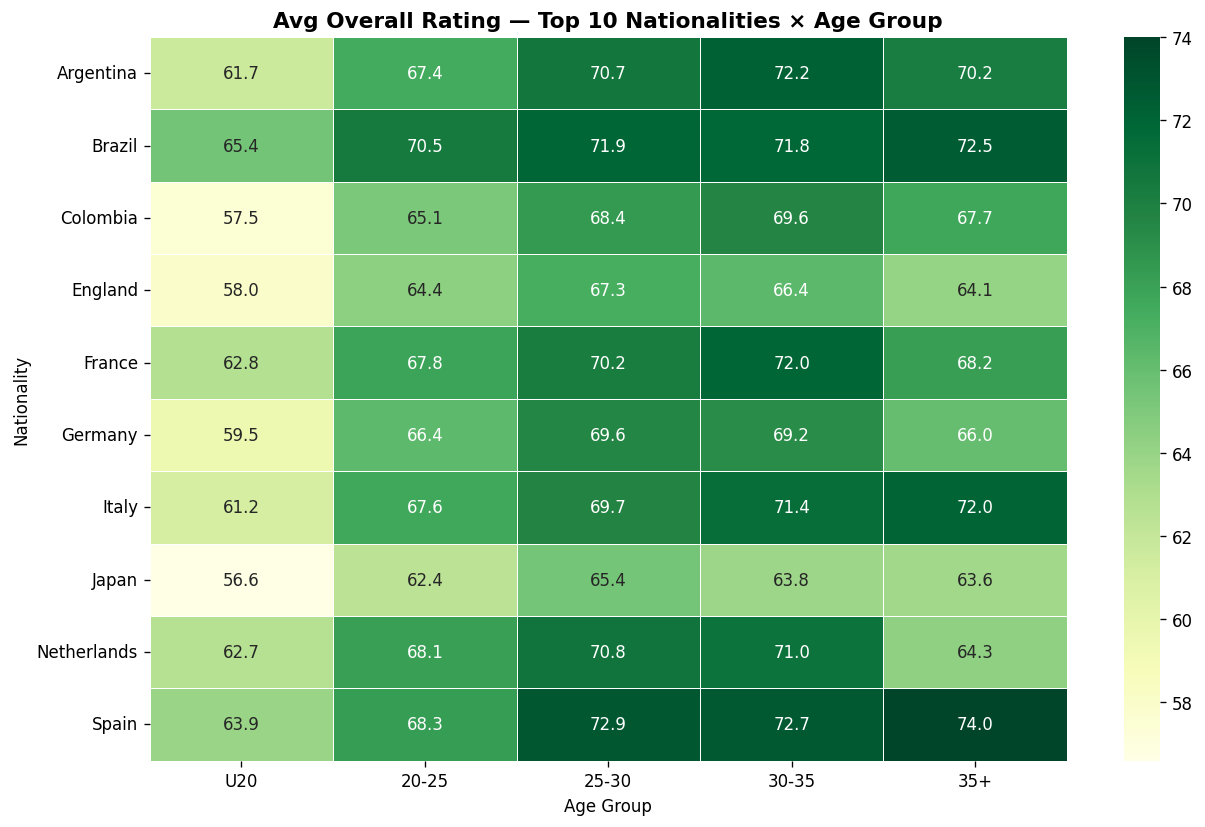

In [28]:
# ─── Chart 14: Heatmap — Avg Overall by Nationality × Age Group ──────────────
top10_nations = df_clean['Nationality'].value_counts().head(10).index
sub = df_clean[df_clean['Nationality'].isin(top10_nations)]
pivot2 = sub.groupby(['Nationality', 'Age Group'], observed=True)['Overall'].mean().unstack()

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlGn', linewidths=0.5, ax=ax)
ax.set_title('Avg Overall Rating — Top 10 Nationalities × Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Nationality')
plt.tight_layout()
plt.savefig('chart_14_nationality_age_overall.png', bbox_inches='tight')
plt.show()


**Why this chart?** A pivot heatmap reveals two-way interactions between nationality, age group, and performance.

**Insights:**
- **Brazil and Spain** produce the highest-rated players in the 25–30 age bracket.
- **Argentina's** U20 players already show above-average ratings — strong youth development.
- **England** has the largest player count but not the highest average ratings — quantity over quality.

**Business Impact:** Scouts targeting specific age-nationality combinations can maximize quality-per-player in recruitment.

**Negative Growth Risk:** Nations with poor U20 ratings signal weak youth development pipelines — a long-term talent supply risk.


#### Chart 15 — Skill Moves, International Reputation vs Market Value

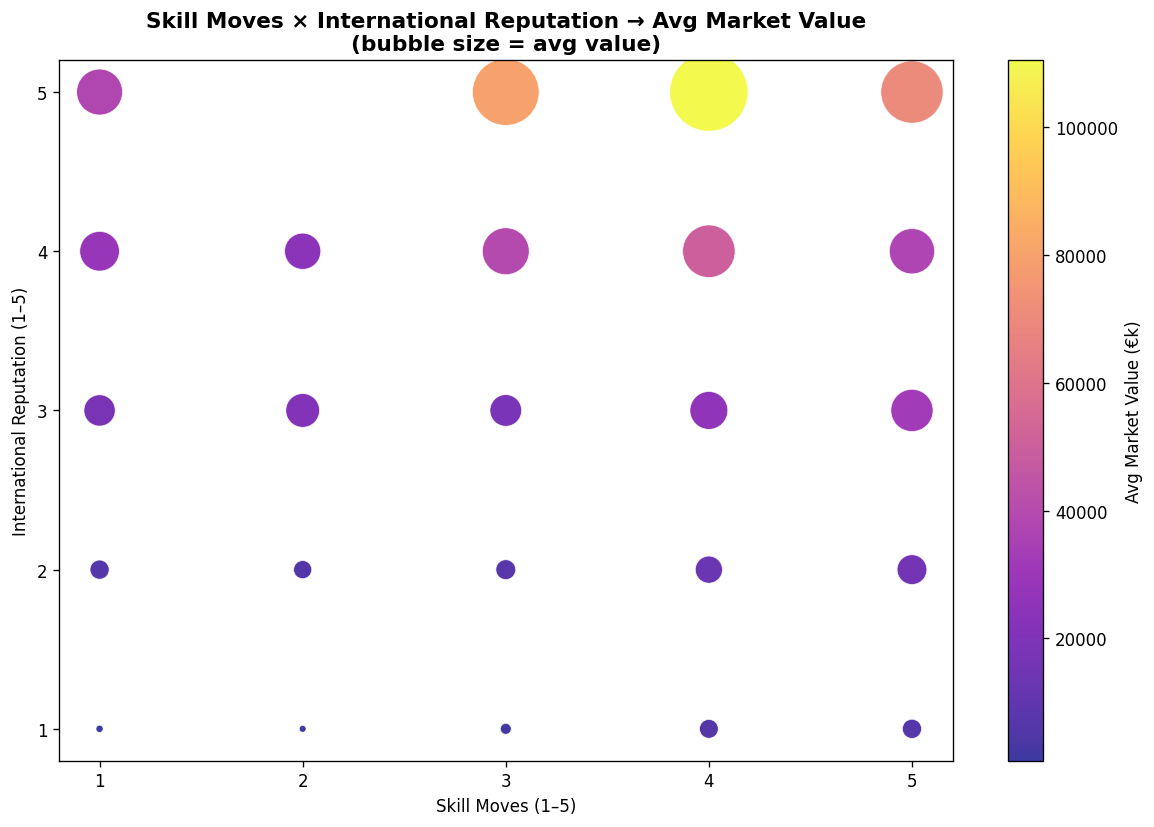

In [30]:
# ─── Chart 15: Bubble Chart — Skill Moves, Reputation, Value ─────────────────
# Aggregate: avg value per (SkillMoves, IntRep) cell
bubble_data = (
    df_clean.groupby(['Skill Moves', 'International Reputation'])
    .agg(Avg_Value=('Value', 'mean'), Count=('Value', 'count'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    bubble_data['Skill Moves'],
    bubble_data['International Reputation'],
    s=bubble_data['Avg_Value'] / 50,        # bubble size scaled
    c=bubble_data['Avg_Value'],
    cmap='plasma', alpha=0.8, edgecolors='white', linewidths=0.5
)
plt.colorbar(sc, ax=ax, label='Avg Market Value (€k)')
ax.set_title('''Skill Moves × International Reputation → Avg Market Value
(bubble size = avg value)''', fontsize=13, fontweight='bold')
ax.set_xlabel('Skill Moves (1–5)')
ax.set_ylabel('International Reputation (1–5)')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('chart_15_bubble_skill_rep_value.png', bbox_inches='tight')
plt.show()

**Why this chart?** A bubble chart encodes 3 variables (Skill Moves, Int. Reputation, Market Value) in a single 2D view.

**Insights:**
- Players with **Skill Moves 5 + Reputation 5** (top-right bubble) command the **highest market values by far**.
- Even **Reputation 3 + Skill Moves 4** players are valued significantly higher than average.
- The relationship is **multiplicative** — both attributes together drive value, not either alone.

**Business Impact:** Clubs can use this 2D grid as a quick "value zone" filter during scouting — targeting the high-rep/high-skill quadrant for marquee signings.

**Negative Growth Risk:** Reputation alone (high rep, low skill) or skill alone (low rep, high skill) does not guarantee proportional value — clubs could overpay without checking both dimensions.


---
## 🏁 Conclusion

This Exploratory Data Analysis of the FIFA 19 dataset revealed several actionable insights across player demographics, performance, finances, and development potential:

1. **Rating Distribution** — Most players cluster in the 60–75 range. Elite (85+) players are rare, commanding exponential wage premiums.
2. **Age & Potential** — The sweet spot for player investment is **ages 18–22 with high Potential Growth**, offering the best long-term ROI.
3. **Left-Foot Scarcity** — Left-footed players (only ~24%) command a position-specific scarcity premium.
4. **Nationality Depth** — England, Germany, and Spain dominate player counts, but Brazil and Spain lead on quality-per-player in prime age groups.
5. **Wage-Value Correlation** — Strong (r≈0.79). However, the relationship is non-linear at the elite end — fair wage benchmarking by rating tier is essential.
6. **Position-Specific Dynamics** — Forwards drive the highest wages and values; Goalkeepers show the most consistent ratings with surprising career longevity.
7. **Release Clause vs Value** — Almost perfectly correlated (r≈0.96) — clubs use market value directly to set clauses.
8. **Skill × Reputation = Value** — Bubble analysis confirms that both Skill Moves and International Reputation must be high for maximum market value.

**Overall:** Data-driven recruitment using this EDA framework can help clubs avoid overpaying for aging stars, identify high-potential undervalued players, and build balanced squads within budget constraints.

---
# 🎉 Hurrah! EDA Capstone Project Successfully Completed!
**Name:** AUNIK SHARMA | **Roll No.:** 29 | **Section:** D2514 | **Reg. No.:** 12503328
